Filas válidas: 703


Archivo HTML guardado


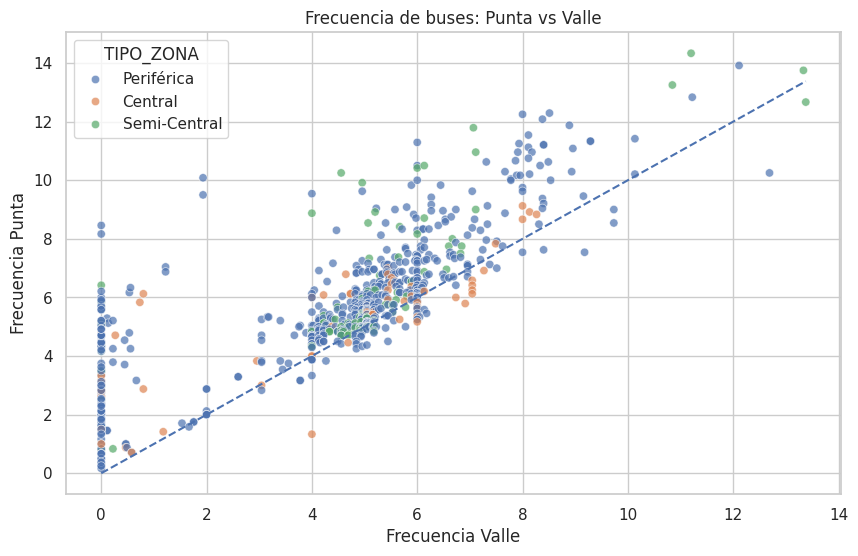

Archivo JPG guardado


In [ ]:
# =====================================================
# INSTALAR DEPENDENCIAS (solo la primera vez)
# =====================================================

!pip install altair vega_datasets -q

# =====================================================
# LIBRERÍAS
# =====================================================

import pandas as pd
import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import HTML, display

# =====================================================
# CARGAR ARCHIVO
# =====================================================

df = pd.read_csv(
    "CONSOLIDADO_ULTRA_LIMPIO.csv",
    sep=None,
    engine="python",
    encoding="latin1",
    on_bad_lines="skip"
)

# =====================================================
# LIMPIAR NOMBRES DE COLUMNAS
# =====================================================

df.columns = df.columns.str.strip()

# =====================================================
# RENOMBRAR COLUMNA
# =====================================================

if "Código Usuario" in df.columns:
    df.rename(
        columns={"Código Usuario": "CODIGO_USUARIO"},
        inplace=True
    )

# =====================================================
# ASEGURAR QUE LAS VARIABLES SEAN NUMÉRICAS
# =====================================================

df["FREC_PUNTA"] = pd.to_numeric(
    df["FREC_PUNTA"],
    errors="coerce"
)

df["FREC_VALLE"] = pd.to_numeric(
    df["FREC_VALLE"],
    errors="coerce"
)

# eliminar nulos

df = df.dropna(
    subset=["FREC_PUNTA", "FREC_VALLE"]
)

print("Filas válidas:", len(df))

# =====================================================
# GRÁFICO INTERACTIVO
# =====================================================

grafico = alt.Chart(df).mark_circle(
    size=80,
    opacity=0.7
).encode(
    x=alt.X(
        "FREC_VALLE:Q",
        title="Frecuencia horario valle"
    ),
    y=alt.Y(
        "FREC_PUNTA:Q",
        title="Frecuencia horario punta"
    ),
    color=alt.Color(
        "TIPO_ZONA:N",
        title="Tipo de zona"
    ),
    tooltip=[
        alt.Tooltip(
            "CODIGO_USUARIO:N",
            title="Código Usuario"
        ),
        alt.Tooltip(
            "TIPO_ZONA:N",
            title="Zona"
        ),
        alt.Tooltip(
            "FREC_PUNTA:Q",
            title="Frecuencia Punta"
        ),
        alt.Tooltip(
            "FREC_VALLE:Q",
            title="Frecuencia Valle"
        )
    ]
).properties(
    width=800,
    height=500,
    title="Frecuencia de buses en horario punta y valle"
).interactive()

# =====================================================
# MOSTRAR GRÁFICO INTERACTIVO EN COLAB
# =====================================================

display(HTML(grafico.to_html()))

# =====================================================
# GUARDAR HTML
# =====================================================

grafico.save("grafico_interactivo.html")

print("Archivo HTML guardado")

# =====================================================
# GUARDAR JPG
# =====================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="FREC_VALLE",
    y="FREC_PUNTA",
    hue="TIPO_ZONA",
    alpha=0.7
)

plt.plot(
    [df["FREC_VALLE"].min(), df["FREC_VALLE"].max()],
    [df["FREC_VALLE"].min(), df["FREC_VALLE"].max()],
    linestyle="--"
)

plt.title("Frecuencia de buses: Punta vs Valle")
plt.xlabel("Frecuencia Valle")
plt.ylabel("Frecuencia Punta")

plt.grid(True)

plt.savefig(
    "grafico_transporte.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Archivo JPG guardado")